In [1]:
import gensim.downloader as api
import warnings 
warnings.filterwarnings('ignore')

In [2]:
model = api.load("word2vec-google-news-300") 

### Calcul de similaritee des mots

In [3]:
model.most_similar(positive=['king', 'woman'], negative='man', topn=1)

[('queen', 0.7118193507194519)]

In [4]:
model.most_similar(positive=['Canada', 'Mexico'], negative='Anglais', topn=1)

[('United_States', 0.585976243019104)]

In [5]:
model.most_similar('hamburger', topn=9)

[('burger', 0.7784732580184937),
 ('hamburgers', 0.729724109172821),
 ('cheeseburger', 0.7115724682807922),
 ('burgers', 0.7085813879966736),
 ('sandwich', 0.6669142246246338),
 ('hotdog', 0.6552070379257202),
 ('taco', 0.6474027633666992),
 ('fries', 0.641411304473877),
 ('burrito', 0.6399032473564148)]

In [6]:
phrases = [
    "le chat mange ses croquettes",
    "le chien aime ses croquettes",
    "le chat ronronne ett mange"
]

## Scoring en utilisant TFIdf

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import numpy as np

In [8]:
vectorizer = CountVectorizer()
vector = vectorizer.fit_transform(phrases)

In [9]:
X = vector.toarray()
df = pd.DataFrame(
    X,
    columns=vectorizer.get_feature_names_out(),
    index=[f"phrase_{i+1}" for i in range(X.shape[0])]
)
df

,aime,chat,chien,croquettes,ett,le,mange,ronronne,ses
phrase_1,0,1,0,1,0,1,1,0,1
phrase_2,1,0,1,1,0,1,0,0,1
phrase_3,0,1,0,0,1,1,1,1,0


In [10]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_vetor = tfidf_vectorizer.fit_transform(phrases)

In [11]:
X = np.around(tfidf_vetor.toarray(), 2)
df = pd.DataFrame(
    X,
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f"doc_{i+1}" for i in range(X.shape[0])]
)
df

,aime,chat,chien,croquettes,ett,le,mange,ronronne,ses
doc_1,0.00,0.47,0.00,0.47,0.00,0.36,0.47,0.00,0.47
doc_2,0.53,0.00,0.53,0.41,0.00,0.32,0.00,0.00,0.41
doc_3,0.00,0.41,0.00,0.00,0.53,0.32,0.41,0.53,0.00


### Distance entre des phrases : 
#### utilisation du calcul de distance : cosin similarity

In [12]:
from scipy.spatial.distance  import cosine

In [13]:
cosine(
    tfidf_vectorizer.transform(['le chat ronronne et mange']).toarray()[0],
    tfidf_vectorizer.transform(['le chat mange ces croquettes']).toarray()[0],
)

np.float64(0.341118214519036)

In [14]:
cosine(
    tfidf_vectorizer.transform(['le chat ronronne et mange']).toarray()[0],
    tfidf_vectorizer.transform(['le chien mange ces croquettes']).toarray()[0],
)

np.float64(0.6299420851316122)

## HYPOTHESE Distributionnel 
    SI : Sens === Contexte
         Contexte -> Vecteur
         Distance(Vect1, Vect2) === Distance(Sens1, Sens2)

In [15]:
from collections import defaultdict

In [26]:
phrases = [
    "le chat mange ces croquettes",
    "les chat et chiens sont tous des animals de race differant"
    "le chien devore de la viande",
    "le chat adore la patee",
    "Jean va travailler",
    "le chat a besoin de manger",
    "Jacque aime les animaux",
    "Jacque joue avec son chien",
    "Luc prepare de la nourriture pour chat"
    "Jean aime quand son animal mange"
]

In [27]:
contexts = defaultdict(list)
for phrase in phrases:
    words = phrase.split()
    for i, word in enumerate(words):
        candidate = [i+j for j in range(-1, 2) if j != 0]
        actual = [c for c in candidate if 0 <= c < len(words)]
        contexts[word] = contexts[word] + [words[a] for a in actual]

In [28]:
for k, v in contexts.items():
    print(f"== {k} ==")
    print(v)
    print()

== le ==
['chat', 'chat', 'chat']

== chat ==
['le', 'mange', 'les', 'et', 'le', 'adore', 'le', 'a']

== mange ==
['chat', 'ces', 'animal']

== ces ==
['mange', 'croquettes']

== croquettes ==
['ces']

== les ==
['chat', 'aime', 'animaux']

== et ==
['chat', 'chiens']

== chiens ==
['et', 'sont']

== sont ==
['chiens', 'tous']

== tous ==
['sont', 'des']

== des ==
['tous', 'animals']

== animals ==
['des', 'de']

== de ==
['animals', 'race', 'devore', 'la', 'besoin', 'manger', 'prepare', 'la']

== race ==
['de', 'differantle']

== differantle ==
['race', 'chien']

== chien ==
['differantle', 'devore', 'son']

== devore ==
['chien', 'de']

== la ==
['de', 'viande', 'adore', 'patee', 'de', 'nourriture']

== viande ==
['la']

== adore ==
['chat', 'la']

== patee ==
['la']

== Jean ==
['va']

== va ==
['Jean', 'travailler']

== travailler ==
['va']

== a ==
['chat', 'besoin']

== besoin ==
['a', 'de']

== manger ==
['de']

== Jacque ==
['aime', 'joue']

== aime ==
['Jacque', 'les', 'chatJ

In [29]:
phrases

['le chat mange ces croquettes',
 'les chat et chiens sont tous des animals de race differantle chien devore de la viande',
 'le chat adore la patee',
 'Jean va travailler',
 'le chat a besoin de manger',
 'Jacque aime les animaux',
 'Jacque joue avec son chien',
 'Luc prepare de la nourriture pour chatJean aime quand son animal mange']

In [30]:
vectorizer = TfidfVectorizer()
vectorizer.fit(phrases)

vectors = {}
for k, v in dict(contexts).items():
    str_ = ' '.join(v)
    vectors[k] = np.around(vectorizer.transform([str_]).toarray(), 2)[0]

In [33]:
print("Espace vectorielle de", len(vectorizer.get_feature_names_out()), 'dimensions')
print(vectorizer.get_feature_names_out())
print()

for k, v in vectors.items():
    print(f"== {k} ==")
    print(v)
    print()

Espace vectorielle de 39 dimensions
['adore' 'aime' 'animal' 'animals' 'animaux' 'avec' 'besoin' 'ces' 'chat'
 'chatjean' 'chien' 'chiens' 'croquettes' 'de' 'des' 'devore'
 'differantle' 'et' 'jacque' 'jean' 'joue' 'la' 'le' 'les' 'luc' 'mange'
 'manger' 'nourriture' 'patee' 'pour' 'prepare' 'quand' 'race' 'son'
 'sont' 'tous' 'travailler' 'va' 'viande']

== le ==
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

== chat ==
[0.35 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.35 0.   0.   0.   0.   0.76 0.29 0.   0.29 0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]

== mange ==
[0.   0.   0.65 0.   0.   0.   0.   0.65 0.41 0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]

== ces ==
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.77 0.
 0.   0.   0.   0.

In [34]:
import matplotlib.pyplot as plt 
import seaborn as sns

def plot(array):
    fig_dims = (20, 1)
    fig, ax = plt.subplots(figsize=fig_dims)
    sns.heatmap([array], cmap="YlGnBu")

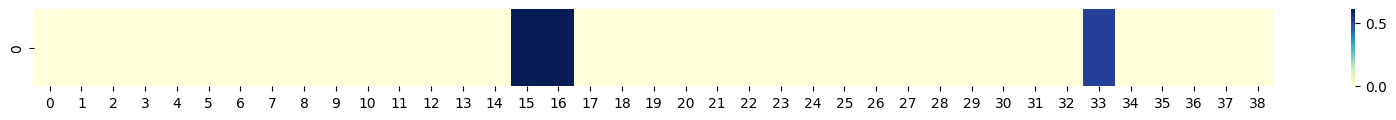

In [35]:
plot(vectors['chien'])

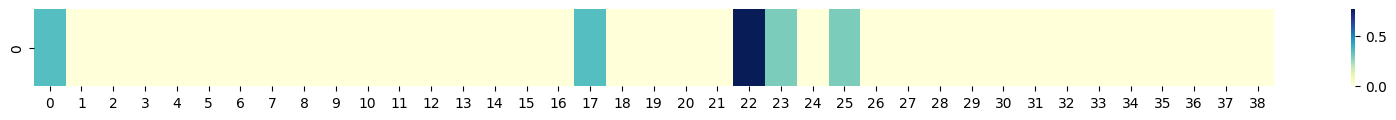

In [36]:
plot(vectors['chat'])

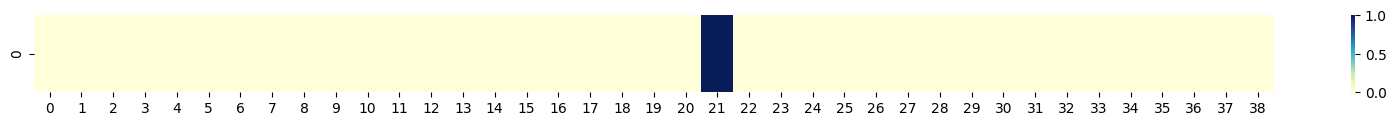

In [44]:
plot(vectors['patee'])

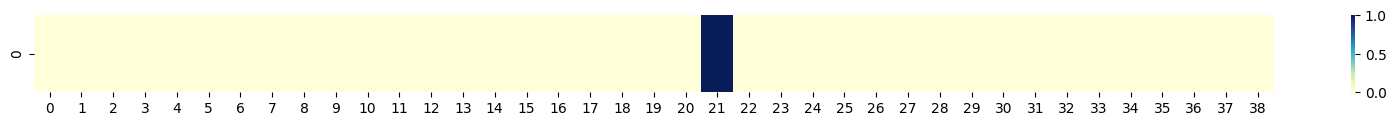

In [45]:
plot(vectors['viande'])

In [37]:
from scipy.spatial.distance import cosine

In [38]:
def most_similar(word):
    scrores = []
    keys_ =  [K for K in vectors.keys() if K!= word]
    for K in keys_:
        scrores.append(
            1-cosine(
                vectors[word],
                vectors[K]
            )
        )
    return pd.Series(
        scrores,
        index=keys_
    ).sort_values(ascending=False).head(1)

In [39]:
most_similar("chat")

animaux    0.291343
dtype: float64

In [40]:
most_similar("chien")

race    0.492009
dtype: float64

In [41]:
most_similar("mange")

croquettes    0.645784
dtype: float64

In [43]:
most_similar("patee")

viande    1.0
dtype: float64